# Pendulum equation
## Dataset generation

In [1]:
import os
import numpy as np
import torch
from torch.utils.data import TensorDataset, ConcatDataset, Subset
from torch import Tensor
from generate import X, U, DU, D2U, PDE_KEYS, PDE_VALUES, IC_KEYS, IC_VALUES, RESIDUAL_KEYS, RESIDUAL_VALUES, TIMES
from plot_utils import plot_timeseries2, plot_points, plot_subsample, plot_phase_portrait, plot_timeseries, plot_timeseries_and_phase_portrait, get_pendulum_animation, plot_dynamics
from pde_utils import key_str, ic_key_str, key_idx
from generate import X, U, generate_from_config
from typing import Tuple, List
from data_utils import extract_targets, extract_boundary, extract_interior, extract_TensorDataset
import yaml
# ------------------------
SEED = 42
PDE = "Pendulum"
PDE_NAME = "Pendulum"

# Number of trajectories to generate
N_TASKS = 1

# Initial conditions
ICS = {
    "u0": {"min": 0.0, "max": 1.0, "samples": []}, # angle
    "du0": {"min": 0.0, "max": 1.0, "samples": []} # angular velocity
}

# Time range
T_MIN, T_MAX = 0.0, 10.0

# Temporal grid resolution
DT = 0.02

# Time instants to store
TIME_SAMPLING = "Const" # Const Log
N_TIME_SAMPLES = 100

N_DEV = 2048
N_INTRA_TEST = 512
N_VAL = 512

# Pendulum GE Parameters
PARAMS = {
    "m": {"min": 1.0, "max": 1.0, "samples": []},
    "l": {"min": 1.0, "max": 1.0, "samples": []},
    "b": {"min": 0.0, "max": 0.0, "samples": []},
    "A": {"min": 10.0, "max": 20.0, "samples": []},
    "w": {"min": 0.0, "max": 10.0, "samples": []},
    "g": {"min": 9.80665, "max": 9.80665, "samples": []}
}

# Name of the .pth dataset file
DATASET_NAME = "varyIC"

os.makedirs(f"{PDE}/data/{DATASET_NAME}/{TIME_SAMPLING}TimeStep", exist_ok=True)

### Functions

In [2]:
def subsample(
    datasets: List[ConcatDataset],
    n_dev_samples: int,
    n_test_samples: int,
    seed=42
    ) -> Tuple[List[ConcatDataset], List[List[Tensor]], List[ConcatDataset], List[List[Tensor]]]:

    dev_reduced_datasets = []
    test_reduced_datasets = []
    last_seed = seed

    dev_indicess = []
    test_indicess = []
    
    for concat_ds in datasets:
        seeds = [last_seed+i for i in range(len(concat_ds.datasets))]
        last_seed = seeds[-1]
        dev_reduced_concat_ds = []
        test_reduced_concat_ds = []
        dev_indices = []
        test_indices = []
        for ds, seed in zip(concat_ds.datasets, seeds):
            torch.manual_seed(seed)
            indices = torch.randperm(len(ds))
            dev_indices.append(indices[:n_dev_samples])
            test_indices.append(indices[n_dev_samples:n_dev_samples+n_test_samples])
            dev_reduced_concat_ds.append(Subset(ds, dev_indices[-1]))
            test_reduced_concat_ds.append(Subset(ds, test_indices[-1]))
        dev_indicess.append(dev_indices)
        test_indicess.append(test_indices)
        dev_reduced_datasets.append(ConcatDataset(dev_reduced_concat_ds))
        test_reduced_datasets.append(ConcatDataset(test_reduced_concat_ds))
    return dev_reduced_datasets, dev_indicess, test_reduced_datasets, test_indicess

def split_train_val(
        dev_datasets: List[ConcatDataset],
        n_val_samples: int,
        seed: int = 42
        ) -> Tuple[List[ConcatDataset], List[List[Tensor]], List[ConcatDataset], List[List[Tensor]]]:
    
    val_datasets = []
    train_datasets = []

    train_indicess = []
    val_indicess = []
    
    for j, concat_ds in enumerate(dev_datasets):
        seeds = [seed+i*j for i in range(len(concat_ds.datasets))]
        train_concat_ds = []
        val_concat_ds = []
        train_indices = []
        val_indices = []
        for ds, seed in zip(concat_ds.datasets, seeds):
            torch.manual_seed(seed)
            indices = torch.randperm(len(ds))
            val_indices.append(indices[:n_val_samples])
            train_indices.append(indices[n_val_samples:])
            train_concat_ds.append(Subset(ds, train_indices[-1]))
            val_concat_ds.append(Subset(ds, val_indices[-1]))
        train_indicess.append(train_indices)
        val_indicess.append(val_indices)
        train_datasets.append(ConcatDataset(train_concat_ds))
        val_datasets.append(ConcatDataset(val_concat_ds))
    return train_datasets, train_indicess, val_datasets, val_indicess

def merge_ds(datasets: list):
    cols = None   
    for ds in datasets:
        new_cols = list(ds.tensors)
        if cols is None:
            cols = new_cols
        else:
            for i, col in enumerate(new_cols):
                cols[i] = torch.cat([cols[i], col])
    return TensorDataset(*cols)

### Data generation

In [3]:
np.random.seed(SEED)

os.makedirs(f"{PDE}/data/{TIME_SAMPLING}TimeStep", exist_ok=True)

# Initial conditions: ~ Uniform [a, b]
for k in ICS.keys():
    ICS[k]["samples"] = np.random.uniform(ICS[k]["min"], ICS[k]["max"], size=(N_TASKS, 1))

# GE parameters: ~ Uniform [a, b]
for k in PARAMS.keys():
    PARAMS[k]["samples"] = np.random.uniform(PARAMS[k]["min"], PARAMS[k]["max"], size=(N_TASKS, 1))

# Temporal grid and samples
if TIME_SAMPLING == "Const":
        time = {"t": [T_MIN, T_MAX], "dt": DT, "n_snapshots": N_TIME_SAMPLES}
elif TIME_SAMPLING == "Log":
    time = {"t": [T_MIN, T_MAX], "dt": DT, "snapshots": 2 * np.logspace(start=-2, stop=0, num=N_TIME_SAMPLES)}

full_datasets = []

for i in range(N_TASKS):
    
    initial_conditions = {}
    for k in ICS.keys():
        initial_conditions[k] = ICS[k]["samples"][i].item()

    parameters = {}
    for k in PARAMS.keys():
        parameters[k] = PARAMS[k]["samples"][i].item()

    config_dict = {
        "PDE": PDE_NAME,
        "time": time,
        "seed": SEED,
        "initial_conditions": initial_conditions,
        "parameters": parameters
    }

    full_datasets.append(generate_from_config(config_dict))

    for k in initial_conditions.keys():
        initial_conditions[k] = initial_conditions[k]
    for k in parameters.keys():
         parameters[k] = parameters[k]

    to_save = {
        "initial_conditions": initial_conditions,
        "parameters": parameters
    }
    with open(f"{PDE}/data/{TIME_SAMPLING}TimeStep/trajectory{i}.yaml", "w") as f:
        yaml.dump(to_save, f)

# Save the datasets list as a ConcatDataset
torch.save(ConcatDataset(full_datasets), f"{PDE}/data/{DATASET_NAME}/{TIME_SAMPLING}TimeStep/dataset.pth")

The solver successfully reached the end of the integration interval.


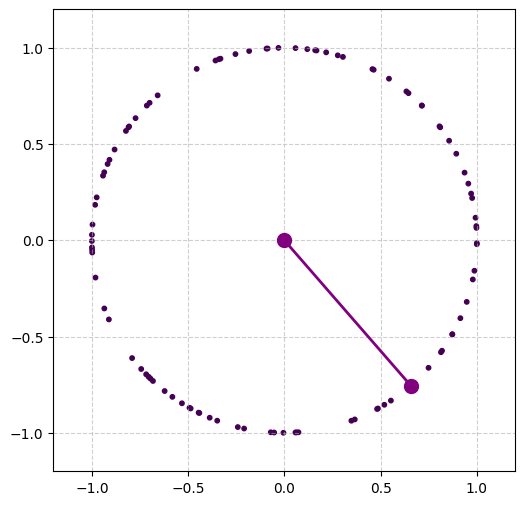

In [4]:
t = np.linspace(0, 10, 200)
u = 0.8 * np.exp(-0.1 * t) * np.cos(5 * t) # Damped oscillation
l = 1.0

trajectory = 0

dataset = merge_ds(torch.load(f"{PDE}/data/{DATASET_NAME}/{TIME_SAMPLING}TimeStep/dataset.pth", weights_only=False).datasets[trajectory].datasets)

t = dataset.tensors[TIMES]
u = dataset.tensors[U]
l_idx = key_idx("l", PDE_NAME)
l = dataset.tensors[RESIDUAL_VALUES][0][l_idx]
get_pendulum_animation(t=t, u=u, l=l, filename=f"{PDE}/simulation.gif")

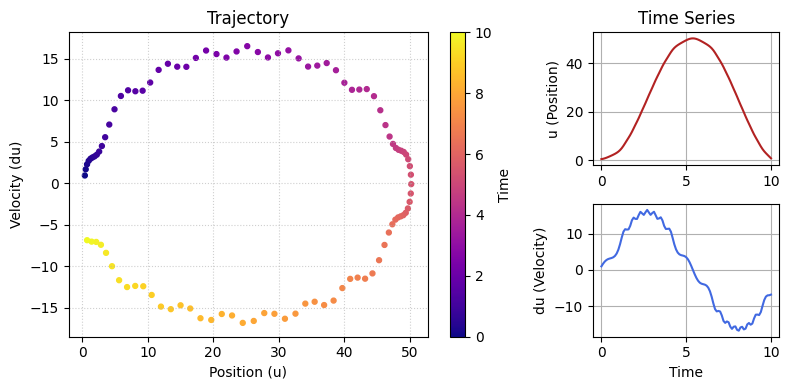

In [5]:
datasets = torch.load(f"{PDE}/data/{DATASET_NAME}/{TIME_SAMPLING}TimeStep/dataset.pth", weights_only=False).datasets

for dataset in datasets:
    plot_dynamics(dataset=merge_ds(dataset.datasets), u_idx=U, du_idx=DU, t_idx=TIMES, figsize=(8, 4), cmap="plasma", color="gray", arrows=False, marker=".", markersize=50)

In [6]:
datasets = torch.load(f"{PDE}/data/{DATASET_NAME}/{TIME_SAMPLING}TimeStep/dataset.pth", weights_only=False).datasets

dev_datasets, dev_indices, _, intra_test_indices = subsample(
    datasets,
    N_DEV,
    N_INTRA_TEST,
    seed=SEED
)
del datasets
_, train_indices, _, val_indices = split_train_val(
    dev_datasets,
    N_VAL,
    seed=SEED
)
del dev_datasets
n_tasks = len(train_indices) # number of tasks
n_test_tasks = 0 #int(0.2 * n_tasks)
n_train_tasks = n_tasks - n_test_tasks
if n_test_tasks != 0:
    inter_test_indices = dev_indices[n_train_tasks:]
dev_indices = dev_indices[:n_train_tasks]
train_indices = train_indices[:n_train_tasks]
val_indices = val_indices[:n_train_tasks]
intra_test_indices = intra_test_indices[:n_train_tasks]

torch.save(dev_indices, f"{PDE}/data/{TIME_SAMPLING}TimeStep/dev_indices.pth")
torch.save(train_indices, f"{PDE}/data/{TIME_SAMPLING}TimeStep/train_indices.pth")
torch.save(val_indices, f"{PDE}/data/{TIME_SAMPLING}TimeStep/val_indices.pth")
torch.save(intra_test_indices, f"{PDE}/data/{TIME_SAMPLING}TimeStep/intra_test_indices.pth")

print(f"|dev| = {len(dev_indices[0][0])} spatial points x {len(dev_indices[0])} temporal points x {len(dev_indices)} tasks")
print(f"|train| = {len(train_indices[0][0])} spatial points x {len(train_indices[0])} temporal points x {len(train_indices)} tasks")
print(f"|val| = {len(val_indices[0][0])} spatial points x {len(val_indices[0])} temporal points x {len(val_indices)} tasks")
if n_test_tasks != 0:
    print(f"|intra_test| = {len(intra_test_indices[0][0])} spatial points x {len(intra_test_indices[0])} temporal points x {len(intra_test_indices)} tasks")

|dev| = 1 spatial points x 101 temporal points x 1 tasks
|train| = 0 spatial points x 101 temporal points x 1 tasks
|val| = 1 spatial points x 101 temporal points x 1 tasks
